# Strong ground motion database

For this tutorial, a sample dataset was gathered by randomly selecting events from the N-TSMD and SMD-TR datasets. For the full datasets, please refer to the relevant publications. <br>

**N-TSMD**: New Turkish Strong Motion Database (Tanırcan et al. 2022)<br>
**SMD-TR**: Strong-Motion Database of Turkiye (Sandıkkaya et al. 2023)<br>

![Seismicity Map](data/seismicity_map.png)

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/gmm_dataset_sample.csv')

print(f"{'Index':<6} | {'Column Name':<45} | {'Data Type':<12} | {'Non-Null Count'}")
print("-" * 85)

# Loop through columns to display metadata
for i, col in enumerate(df.columns):
    dtype = str(df[col].dtype)
    non_null = df[col].count() # Number of non-empty cells
    print(f"{i:<6} | {col:<45} | {dtype:<12} | {non_null}")

print("-" * 85)
print(f"Total Columns: {len(df.columns)}")

Index  | Column Name                                   | Data Type    | Non-Null Count
-------------------------------------------------------------------------------------
0      | EQID                                          | int64        | 8956
1      | Mw                                            | float64      | 8956
2      | SoF                                           | object       | 8956
3      | Dip                                           | float64      | 8956
4      | RJB                                           | float64      | 8956
5      | VS30                                          | float64      | 8956
6      | PGV_geo                                       | float64      | 8956
-------------------------------------------------------------------------------------
Total Columns: 7


In [3]:
# Summary of dataset
num_cols = ['Mw', 'Dip', 'RJB', 'VS30', 'PGV_geo']
summary_df = df[num_cols].describe().T[['count', 'mean', 'std', 'min', 'max']]

summary_df['num_events'] = df['EQID'].nunique()
summary_df['dtype'] = df[num_cols].dtypes

summary_df = summary_df.rename(columns={
    'count': 'Total Record Count',
    'num_events': 'Unique EQ Events',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    'max': 'Max',
    'dtype': 'Data Type'
})

summary_df = summary_df[['Data Type', 'Total Record Count', 'Unique EQ Events', 'Mean', 'Std Dev', 'Min', 'Max']]

print("Ground Motion Dataset Summary Table: ")
display(summary_df.round(3))

Ground Motion Dataset Summary Table: 


,Data Type,Total Record Count,Unique EQ Events,Mean,Std Dev,Min,Max
Mw,float64,8956.0,812,4.556,0.616,3.500,7.800
Dip,float64,8956.0,812,60.350,17.677,10.590,90.000
RJB,float64,8956.0,812,98.756,47.330,0.000,199.400
VS30,float64,8956.0,812,474.848,240.770,131.000,1862.000
PGV_geo,float64,8956.0,812,0.464,4.630,0.001,171.297


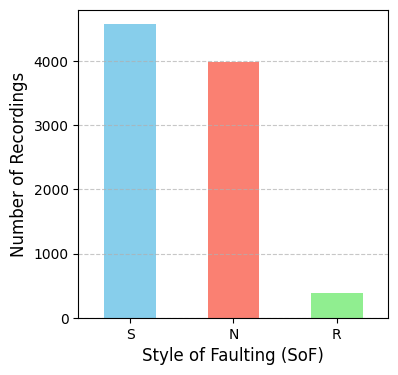

In [4]:
# SoF distribution plot
sof_counts = df['SoF'].value_counts()

plt.figure(figsize=(4, 4))
sof_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])

plt.xlabel('Style of Faulting (SoF)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

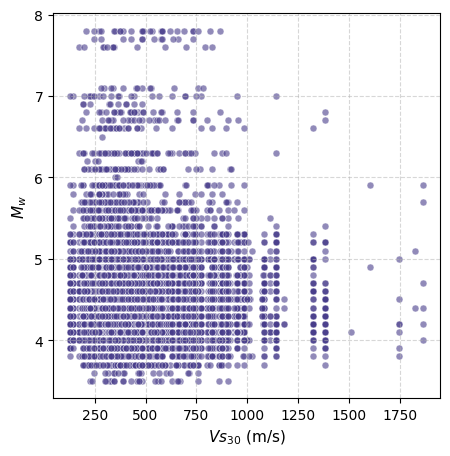

In [5]:
# Mw vs Vs30
plt.figure(figsize=(5, 5))
plt.scatter(df['VS30'], df['Mw'], alpha=0.6, s=25, color='darkslateblue', edgecolors='white', linewidth=0.5)

plt.xlabel('$Vs_{30}$ (m/s)', fontsize=11)
plt.ylabel('$M_w$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

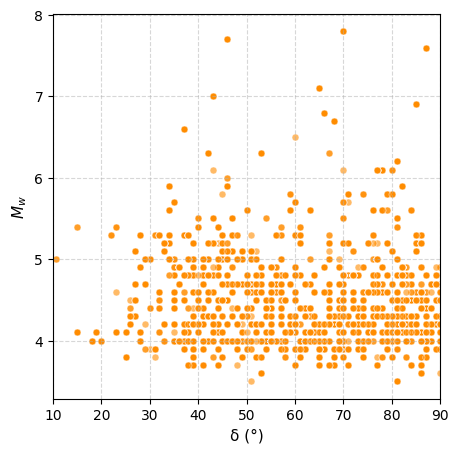

In [6]:
# Mw vs Dip Angle
plt.figure(figsize=(5, 5))
plt.scatter(df['Dip'], df['Mw'], alpha=0.6, s=25, color='darkorange', edgecolors='white', linewidth=0.5)

plt.xlabel('δ (°)', fontsize=11)
plt.ylabel('$M_w$', fontsize=11)
plt.xlim([10, 90])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

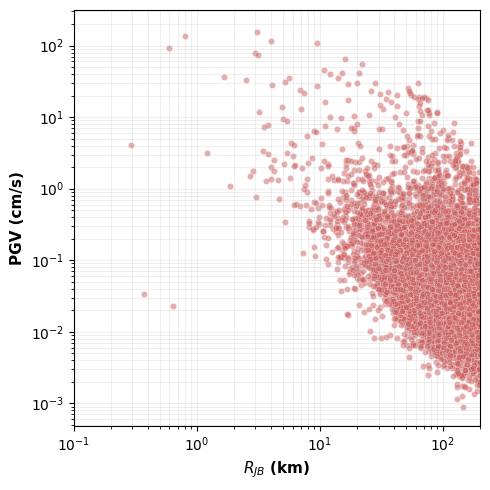

In [7]:
#PGV vs Rjb
df['PGV_geomean'] = df['PGV_geo']

# Plot
plt.figure(figsize=(5, 5))

plt.scatter(
    df['RJB'], df['PGV_geomean'], 
    alpha=0.5, s=20, color='indianred', 
    edgecolors='white', linewidth=0.3
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$R_{JB}$ (km)', fontsize=11, fontweight='bold')
plt.ylabel('PGV (cm/s)', fontsize=11, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim([0.1, 200])

plt.tight_layout()
plt.show()